# 2.0 · 모델링 (기준선 vs 개선모델 vs 대안모델 비교)

**목표**: `1.0-eda.ipynb`에서 확인한 것처럼, 카페1개당 평균매출과 가장 강하게 관련된 변수는 총_직장_인구_수(r≈0.76)였습니다. 이 노트북에서는 그 관계를 실제 회귀모델로 만들고, (1) 변수를 하나만 쓴 기준선 모델과 다른 변수를 추가한 개선 모델을 비교하고, (2) 선형회귀가 아닌 다른 모델(랜덤포레스트)도 실제로 돌려서 왜 이 프로젝트에는 맞지 않는지 결과로 확인합니다.

**평가지표를 R²/LOOCV로 쓰는 이유**: 이 프로젝트는 "새 지역의 매출을 정확히 맞히는 예측 모델"이 아니라 "왜 어떤 자치구는 카페 매출이 높은지 설명하는 모델"이 목표입니다. 그래서 정확도·RMSE 단독이 아니라, 설명력을 나타내는 **R²**와, 처음 보는 데이터에도 그 설명력이 유지되는지를 보는 **LOOCV(Leave-One-Out Cross-Validation)**를 같이 봅니다. LOOCV는 자치구 하나를 빼고 나머지로 학습 → 뺀 자치구를 예측 → 이걸 25번(자치구 수만큼) 반복해서 얻은 예측들로 계산한 R²입니다. 전체학습 R²(가진 데이터를 그대로 다시 맞혀본 점수)만 보면 모델이 얼마나 "외웠는지"까지 좋게 나올 수 있어서, 두 점수를 같이 봐야 진짜 설명력인지 과적합인지 구분할 수 있습니다.

**표본 크기 제약**: 회귀에 쓸 수 있는 배후 수요 변수(총_직장_인구_수, 총_상주인구_수, 총_가구_수, 총_유동인구_수, 집객시설_수, 지하철_역_수 등)는 **자치구 단위 표에만 있고, 행정동 단위 표(420개)에는 없습니다.** 그래서 이 모델이 쓸 수 있는 표본은 사실상 자치구 25개뿐입니다. 표본이 이렇게 작을 때는 변수를 무한정 추가할 수 없고(추가할수록 과적합 위험이 커짐), 랜덤포레스트·XGBoost처럼 복잡한 모델도 데이터 25개로는 패턴이 아니라 잡음까지 외워버리기 쉽습니다 — 이 노트북 마지막에서 실제로 확인합니다.

## STEP 1. 데이터 로드

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import r2_score
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

sns.set_style("whitegrid")
# Windows에서 한글이 깨지지 않도록 폰트를 지정합니다. (다른 컴퓨터에서 실행 시 설치된 한글 폰트로 바꿔주세요)
# 주의: sns.set_style()이 font.family를 다시 초기화하므로, 반드시 그 다음에 폰트를 지정해야 합니다.
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# ------------------------------------------------------------
# 실행 전 확인: 이 변수만 본인 컴퓨터의 프로젝트 경로로 바꿔주세요.
# ------------------------------------------------------------
프로젝트_루트 = r"C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정"

종합표_경로 = 프로젝트_루트 + r"\data\processed\서울_자치구_카페_종합표.csv"
df = pd.read_csv(종합표_경로, encoding="utf-8-sig")

df["log_직장인구"] = np.log(df["총_직장_인구_수"])
y = df["카페1개당_평균매출"].values

print("표본 크기:", len(df), "개 자치구")
df[["자치구_코드_명", "카페1개당_평균매출", "총_직장_인구_수", "log_직장인구"]].head(3)

표본 크기: 25 개 자치구


,자치구_코드_명,카페1개당_평균매출,총_직장_인구_수,log_직장인구
0,강동구,1.769497e+07,51554,10.850385
1,송파구,2.581630e+07,409883,12.923627
2,강남구,4.140373e+07,1079924,13.892401


## STEP 2. LOOCV 함수 준비 + 기준선 모델

`13~18번` 부산·경남 노트북에서 썼던 것과 같은 방식의 LOOCV 함수를 그대로 씁니다. 기준선은 1.0-eda에서 가장 강한 상관을 보였던 log(총_직장_인구_수) 하나만 쓴 모델입니다.

In [2]:
def loocv_평가(X, y, 모델_생성함수):
    """Leave-One-Out Cross-Validation: 표본을 하나씩 빼고 예측 -> 전체 예측을 모아 R² 계산"""
    loo = LeaveOneOut()
    예측값 = np.zeros(len(y))
    for train_idx, test_idx in loo.split(X):
        모델 = 모델_생성함수()
        모델.fit(X[train_idx], y[train_idx])
        예측값[test_idx] = 모델.predict(X[test_idx])
    return r2_score(y, 예측값), 예측값


X_기준선 = df[["log_직장인구"]].values
모델_기준선 = LinearRegression().fit(X_기준선, y)
r2_기준선_전체 = r2_score(y, 모델_기준선.predict(X_기준선))
r2_기준선_loocv, _ = loocv_평가(X_기준선, y, lambda: LinearRegression())

print("=== 기준선 모델: log(총_직장_인구_수) 1개 변수 ===")
print(f"전체학습 R² = {r2_기준선_전체:.4f}   |   LOOCV R² = {r2_기준선_loocv:.4f}")
print(f"(둘의 차이 {r2_기준선_전체 - r2_기준선_loocv:.4f} -> 차이가 크지 않아 과적합 걱정은 적은 편)")

=== 기준선 모델: log(총_직장_인구_수) 1개 변수 ===
전체학습 R² = 0.6748   |   LOOCV R² = 0.6137
(둘의 차이 0.0611 -> 차이가 크지 않아 과적합 걱정은 적은 편)


## STEP 3. 변수를 하나씩 추가해보며 개선모델 탐색

직장인구 하나로 설명이 안 되는 부분을 다른 변수가 보충해줄 수 있는지, 1.0-eda의 상관관계 분석에서 나온 후보 8개를 하나씩 추가해보고 LOOCV R²가 실제로 좋아지는지 확인합니다. (전체학습 R²만 보면 항상 좋아지는 것처럼 보이므로, LOOCV R² 기준으로 판단합니다.)

In [3]:
후보_변수 = ["총_가구_수", "지하철_역_수", "컨셉_적합도", "운영_영업_개월_평균",
         "전체_점포_수", "집객시설_수", "총_유동인구_수", "총_상주인구_수"]

결과 = []
for 변수 in 후보_변수:
    X = df[["log_직장인구", 변수]].values
    전체_R2 = r2_score(y, LinearRegression().fit(X, y).predict(X))
    loocv_R2, _ = loocv_평가(X, y, lambda: LinearRegression())
    결과.append({"추가한_변수": 변수, "전체학습_R2": round(전체_R2, 4), "LOOCV_R2": round(loocv_R2, 4)})

탐색표 = pd.DataFrame(결과).sort_values("LOOCV_R2", ascending=False).reset_index(drop=True)
탐색표

,추가한_변수,전체학습_R2,LOOCV_R2
0,총_가구_수,0.7668,0.6816
1,총_상주인구_수,0.7673,0.6770
2,운영_영업_개월_평균,0.7352,0.6206
3,전체_점포_수,0.6838,0.5938
4,컨셉_적합도,0.6810,0.5883
5,지하철_역_수,0.6764,0.5830
6,집객시설_수,0.6750,0.5718
7,총_유동인구_수,0.0001,-0.2719


`총_가구_수`를 추가했을 때 LOOCV R²가 0.6137 → 0.6816으로 가장 크게 좋아집니다(`총_상주인구_수`도 비슷하게 좋아지지만, 총_가구_수와 총_상주인구_수는 서로 상관이 0.96으로 사실상 같은 정보라서 하나만 쓰면 됩니다 — 아래에서 다시 확인). 게다가 `log_직장인구`와 `총_가구_수`의 상관은 -0.05로 거의 겹치지 않는 독립적인 정보라, 다중공선성 걱정 없이 안심하고 추가할 수 있는 변수입니다.

2단계로, `log_직장인구 + 총_가구_수`에 세 번째 변수를 하나 더 추가해서 LOOCV가 더 좋아지는지 확인합니다.

In [4]:
후보_변수_2단계 = ["지하철_역_수", "컨셉_적합도", "운영_영업_개월_평균",
            "전체_점포_수", "집객시설_수", "총_유동인구_수", "총_상주인구_수"]

결과_2단계 = []
for 변수 in 후보_변수_2단계:
    X = df[["log_직장인구", "총_가구_수", 변수]].values
    전체_R2 = r2_score(y, LinearRegression().fit(X, y).predict(X))
    loocv_R2, _ = loocv_평가(X, y, lambda: LinearRegression())
    결과_2단계.append({"추가한_변수": 변수, "전체학습_R2": round(전체_R2, 4), "LOOCV_R2": round(loocv_R2, 4)})

탐색표_2단계 = pd.DataFrame(결과_2단계).sort_values("LOOCV_R2", ascending=False).reset_index(drop=True)
탐색표_2단계

,추가한_변수,전체학습_R2,LOOCV_R2
0,집객시설_수,0.8537,0.7778
1,컨셉_적합도,0.7872,0.6823
2,지하철_역_수,0.7818,0.6619
3,전체_점포_수,0.8030,0.6609
4,운영_영업_개월_평균,0.7722,0.6579
5,총_상주인구_수,0.7689,0.6491
6,총_유동인구_수,0.3008,0.0037


`집객시설_수`를 세 번째로 추가했을 때 LOOCV R²가 0.6816 → 0.7778로 다시 한번 크게 좋아집니다. `log_직장인구·총_가구_수·집객시설_수` 세 변수 사이 상관은 0.5 전후로 어느 정도 겹치긴 하지만(다중공선성 완전히 없다고는 못 함 — 한계로 남겨둠), 자치구 표본이 25개뿐인 걸 감안하면 변수 3개(표본 대 변수 비율 약 8:1)가 안정적으로 추정할 수 있는 한계에 가깝습니다. 4번째 변수까지 넣으면 어떻게 되는지 마지막으로 확인해봅니다.

In [5]:
후보_변수_3단계 = ["지하철_역_수", "컨셉_적합도", "운영_영업_개월_평균",
            "전체_점포_수", "총_유동인구_수", "총_상주인구_수"]

결과_3단계 = []
for 변수 in 후보_변수_3단계:
    X = df[["log_직장인구", "총_가구_수", "집객시설_수", 변수]].values
    전체_R2 = r2_score(y, LinearRegression().fit(X, y).predict(X))
    loocv_R2, _ = loocv_평가(X, y, lambda: LinearRegression())
    결과_3단계.append({"추가한_변수": 변수, "전체학습_R2": round(전체_R2, 4), "LOOCV_R2": round(loocv_R2, 4)})

탐색표_3단계 = pd.DataFrame(결과_3단계).sort_values("LOOCV_R2", ascending=False).reset_index(drop=True)
탐색표_3단계

,추가한_변수,전체학습_R2,LOOCV_R2
0,운영_영업_개월_평균,0.8580,0.7726
1,총_상주인구_수,0.8716,0.7720
2,전체_점포_수,0.8565,0.7581
3,컨셉_적합도,0.8604,0.7564
4,지하철_역_수,0.8537,0.7422
5,총_유동인구_수,0.7270,0.5883


4번째 변수는 무엇을 추가해도 LOOCV R²가 0.7778보다 높아지지 않습니다(최고가 운영_영업_개월_평균의 0.7726으로, 오히려 살짝 낮음) — 변수를 더 넣는 건 표본 25개 기준으로는 도움이 안 되고 과적합 위험만 키운다는 뜻입니다. 그래서 **`log_직장인구 + 총_가구_수 + 집객시설_수`, 변수 3개짜리 모델을 최종 개선모델로 채택**합니다.

### STEP 3-부록. 변수 선택 방식 점검 — 선택편향(다중비교) 위험 확인

방금까지 후보 변수를 순서대로 시도해보고 LOOCV가 가장 좋아지는 것을 골랐습니다. 그런데 "여러 후보를 시도해보고 그중 제일 좋은 걸 고르는" 방식 자체에는 위험이 하나 있습니다 — 후보를 충분히 많이 시도하면, 실제로는 매출과 아무 관련이 없어도 그중 하나는 순전히 우연으로 LOOCV 점수가 좋게 나올 수 있습니다(통계학에서 다중비교 문제·p-hacking이라고 부르는 현상과 같은 원리). 우리 변수 선택 과정도 이 위험에서 완전히 자유로운지 확인하기 위해, 카페 매출과 전혀 관련 없는 순수 난수 변수를 만들어 기존 3변수 모델에 하나씩 추가해보고, LOOCV가 "우연히" 좋아지는 것처럼 보이는 경우가 얼마나 되는지 세어봅니다.

In [6]:
변수_최종후보 = ["log_직장인구", "총_가구_수", "집객시설_수"]
X_최종후보 = df[변수_최종후보].values
기준_loocv, _ = loocv_평가(X_최종후보, y, lambda: LinearRegression())

rng = np.random.default_rng(0)
개선된_횟수 = 0
최고_loocv = 기준_loocv

for i in range(50):
    난수_변수 = rng.normal(size=(len(y), 1))  # 카페 매출과 아무 관련 없는 순수 난수
    X_시도 = np.hstack([X_최종후보, 난수_변수])
    loocv_R2, _ = loocv_평가(X_시도, y, lambda: LinearRegression())
    if loocv_R2 > 기준_loocv:
        개선된_횟수 += 1
    최고_loocv = max(최고_loocv, loocv_R2)

print(f"기존 3변수 모델 LOOCV R² = {기준_loocv:.4f}")
print(f"아무 의미 없는 난수를 하나씩 추가해본 50번 중, LOOCV가 우연히 더 좋아 보인 경우: {개선된_횟수}개")
print(f"50번 중 우연히 가장 좋았던 LOOCV R² = {최고_loocv:.4f}")

기존 3변수 모델 LOOCV R² = 0.7778
아무 의미 없는 난수를 하나씩 추가해본 50번 중, LOOCV가 우연히 더 좋아 보인 경우: 12개
50번 중 우연히 가장 좋았던 LOOCV R² = 0.8489


아무 의미 없는 난수를 넣어도 50번 중 12번은 LOOCV가 더 좋아 보였고, 운이 가장 좋았던 경우는 LOOCV R²가 0.85까지 나왔습니다 — 이는 우리가 실제로 채택한 집객시설_수(0.78)보다도 높은 수치입니다. 즉 LOOCV도 "여러 후보를 무작정 많이 시도하면" 완전히 안전하지는 않다는 뜻입니다.

**그래서 이 프로젝트에서는 이 위험을 다음과 같이 줄였습니다.**

1. 무작위 숫자가 아니라, 카페 매출과 관련 있을 법한 이유가 있는 변수 8개만 후보로 시도했습니다(수십~수백 개를 마구잡이로 던져보지 않음).
2. 채택된 변수의 계수 부호가 실제로 설명 가능합니다 — 총_가구_수(음수: 주거지 성격일수록 매출 낮음), 집객시설_수(양수: 유동인구 시설 많을수록 매출 높음). 순수 우연이었다면 이렇게 그럴듯한 해석이 따라붙기 어렵습니다.
3. 4번째 변수를 추가했을 때는 전부 LOOCV가 떨어지거나 비슷했습니다(하나도 개선되지 않음) — 계속 운 좋게 좋아지는 패턴은 아니라는 신호입니다.

다만 표본이 25개뿐인 이상 이 위험을 완전히 없앨 수는 없습니다. 그래서 이건 이 프로젝트의 명시적인 한계로 리포트에도 남깁니다 — 선택된 변수의 설명력에는 어느 정도의 선택편향이 섞여 있을 수 있으며, 더 많은 분기·연도 데이터가 확보되면 재검증이 필요합니다.

## STEP 4. 기준선 vs 개선모델 최종 비교

In [7]:
변수_개선 = ["log_직장인구", "총_가구_수", "집객시설_수"]
X_개선 = df[변수_개선].values

모델_개선 = LinearRegression().fit(X_개선, y)
r2_개선_전체 = r2_score(y, 모델_개선.predict(X_개선))
r2_개선_loocv, loocv_예측값 = loocv_평가(X_개선, y, lambda: LinearRegression())

비교표 = pd.DataFrame([
    {"모델": "기준선 (log직장인구 1개)", "전체학습_R2": round(r2_기준선_전체, 4), "LOOCV_R2": round(r2_기준선_loocv, 4)},
    {"모델": "개선모델 (3개 변수)", "전체학습_R2": round(r2_개선_전체, 4), "LOOCV_R2": round(r2_개선_loocv, 4)},
])
비교표["과적합_정도(전체-LOOCV)"] = (비교표["전체학습_R2"] - 비교표["LOOCV_R2"]).round(4)
비교표

,모델,전체학습_R2,LOOCV_R2,과적합_정도(전체-LOOCV)
0,기준선 (log직장인구 1개),0.6748,0.6137,0.0611
1,개선모델 (3개 변수),0.8537,0.7778,0.0759


개선모델은 기준선 대비 LOOCV R²가 0.6137 → 0.7778로 뚜렷하게 좋아졌고, 전체학습-LOOCV 차이도 0.076 정도로 크지 않습니다(과적합이 아니라 진짜 설명력이 늘어난 것으로 판단). 즉 "직장인구가 많다"는 것만으로는 부족하고, "가구 수가 적을수록(주거지 성격이 약할수록)"·"집객시설이 많을수록" 카페 매출이 추가로 더 높다는 게 데이터로 확인됩니다.

계수 부호도 다음 STEP에서 해석해봅니다.

### R²만으로는 감이 안 오는 부분 — MAE·RMSE로 실제 단위(원) 확인

R²는 "설명력 비율"이라 0.78이 실제로 얼마나 잘 맞춘다는 건지 감이 잘 오지 않습니다. 그래서 "평균적으로 몇 만원 정도 틀리는지"를 보여주는 **MAE(평균절대오차)**와, 큰 오차에 더 민감한 **RMSE(평균제곱근오차)**를 같이 확인합니다. 이 프로젝트에서 회귀모델의 목표는 "새 지역의 매출을 정확히 맞히는 것"이 아니라 "매출과 관련된 요인을 설명하는 것"이라 R²/LOOCV를 주 지표로 썼지만, MAE·RMSE는 그 설명력이 실제로 얼마나 쓸모 있는 수준인지 원 단위 감각을 더해주는 보조 지표로 유용합니다.

In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

_, loocv_예측값_기준선 = loocv_평가(X_기준선, y, lambda: LinearRegression())

def mae_만원(실제, 예측):
    return round(mean_absolute_error(실제, 예측) / 10000, 1)

def rmse_만원(실제, 예측):
    return round(np.sqrt(mean_squared_error(실제, 예측)) / 10000, 1)

지표표 = pd.DataFrame([
    {"모델": "기준선 (log직장인구 1개)", "구분": "전체학습", "MAE(만원)": mae_만원(y, 모델_기준선.predict(X_기준선)), "RMSE(만원)": rmse_만원(y, 모델_기준선.predict(X_기준선))},
    {"모델": "기준선 (log직장인구 1개)", "구분": "LOOCV",   "MAE(만원)": mae_만원(y, loocv_예측값_기준선),            "RMSE(만원)": rmse_만원(y, loocv_예측값_기준선)},
    {"모델": "개선모델 (3개 변수)",     "구분": "전체학습", "MAE(만원)": mae_만원(y, 모델_개선.predict(X_개선)),      "RMSE(만원)": rmse_만원(y, 모델_개선.predict(X_개선))},
    {"모델": "개선모델 (3개 변수)",     "구분": "LOOCV",   "MAE(만원)": mae_만원(y, loocv_예측값),                   "RMSE(만원)": rmse_만원(y, loocv_예측값)},
])
지표표

,모델,구분,MAE(만원),RMSE(만원)
0,기준선 (log직장인구 1개),전체학습,410.2,539.3
1,기준선 (log직장인구 1개),LOOCV,445.7,587.7
2,개선모델 (3개 변수),전체학습,294.6,361.7
3,개선모델 (3개 변수),LOOCV,361.0,445.8


LOOCV 기준으로 보면 기준선 모델은 평균적으로 약 **446만원**(MAE), 큰 오차에 더 민감한 RMSE로는 약 **588만원** 정도 틀립니다. 개선모델은 이 오차가 각각 **361만원·446만원**으로 줄어듭니다 — MAE 기준 약 19%, RMSE 기준 약 24% 오차가 줄어든 셈이라, R²가 0.61 → 0.78로 좋아진 것과 같은 방향으로 "실제로 더 잘 맞춘다"는 걸 원 단위로도 확인할 수 있습니다. 다만 이 수치가 "새 지역의 매출을 몇만원 오차로 예측할 수 있다"는 뜻은 아닙니다 — 이 모델의 목표는 예측이 아니라 설명이고, 표본이 25개뿐이라 오차 자체도 불안정할 수 있어 R²/LOOCV R²를 주 지표로 계속 사용합니다.

In [9]:
계수표 = pd.DataFrame({
    "변수": 변수_개선,
    "계수": 모델_개선.coef_.round(2),
})
print("절편:", round(모델_개선.intercept_, 2))
계수표

절편: -28043343.16


,변수,계수
0,log_직장인구,4405015.65
1,총_가구_수,-103.29
2,집객시설_수,8597.32


`총_가구_수`의 계수가 음수입니다 — 다른 조건이 같을 때 가구 수가 많은(주거지 성격이 강한) 자치구일수록 카페1개당 평균매출이 낮은 경향이 있다는 뜻입니다. `log_직장인구`와 `집객시설_수`는 둘 다 양수라, 직장인구가 많고 집객시설(관공서·병원·학교·역 등)이 많은 곳일수록 매출이 높습니다. 세 변수를 종합하면 **"주거지보다 업무·상업 기능이 강한 자치구"**가 카페 매출이 높다는 그림이 됩니다.

### STEP 4-부록. 모델 가정 점검 — 다중공선성(VIF) & 계수의 통계적 유의성

지금까지의 계수 해석을 신뢰하려면 두 가지를 더 확인해야 합니다.

**(1) 다중공선성(VIF)**: 세 변수(log_직장인구·총_가구_수·집객시설_수)끼리 서로 겹치면 "이 효과가 어느 변수 몫인지"를 모델이 가려내지 못하고, 계수가 표본이 조금만 달라져도 크게 흔들릴 수 있습니다. VIF(분산팽창인자)는 이걸 숫자로 확인하는 지표로, 1이면 다른 변수와 전혀 안 겹친다는 뜻이고 통상 5를 넘으면 주의, 10을 넘으면 문제로 봅니다.

**(2) 계수의 통계적 유의성**: `sklearn`의 `LinearRegression`은 계수만 알려줄 뿐 "이 계수가 우연히 0이 아닌 것처럼 보이는 건 아닌지"는 알려주지 않습니다. 표본이 25개뿐이라 이 확인이 특히 중요해서, `statsmodels`로 같은 모델을 다시 적합해 p-value와 95% 신뢰구간을 함께 봅니다.

In [10]:
X_const = sm.add_constant(df[변수_개선])
ols_모델 = sm.OLS(y, X_const).fit()

vif_df = pd.DataFrame({
    "변수": X_const.columns,
    "VIF": [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
})
vif_df = vif_df[vif_df["변수"] != "const"].reset_index(drop=True)
print("=== 다중공선성(VIF) ===")
print(vif_df.to_string(index=False))

print("\n=== 계수 유의성 (statsmodels OLS) ===")
유의성표 = pd.DataFrame({
    "계수": ols_모델.params.drop("const").round(2),
    "표준오차": ols_모델.bse.drop("const").round(2),
    "p_value": ols_모델.pvalues.drop("const").round(4),
    "ci_low": ols_모델.conf_int()[0].drop("const").round(2),
    "ci_high": ols_모델.conf_int()[1].drop("const").round(2),
})
유의성표

=== 다중공선성(VIF) ===
      변수      VIF
log_직장인구 2.009559
  총_가구_수 2.084426
  집객시설_수 2.985101

=== 계수 유의성 (statsmodels OLS) ===


,계수,표준오차,p_value,ci_low,ci_high
log_직장인구,4405015.65,1020853.26,0.0003,2282035.08,6527996.21
총_가구_수,-103.29,20.40,0.0001,-145.71,-60.87
집객시설_수,8597.32,2435.47,0.0020,3532.48,13662.16


VIF는 세 변수 모두 3 미만(log_직장인구 2.01, 총_가구_수 2.08, 집객시설_수 2.99)으로 기준(5)을 밑돕니다 — 앞서 "상관 0.5 전후의 다중공선성이 일부 남아있다"고 짚었지만, VIF로 다시 확인해보면 계수 추정이 불안정해질 정도로 심각한 수준은 아닙니다. 세 변수의 계수를 각각 독립적인 효과로 읽어도 크게 무리가 없습니다.

계수 유의성도 세 변수 모두 p<0.05로 통계적으로 유의합니다(표본 25개라는 걸 감안하면 특히 총_가구_수·log_직장인구의 p-value가 0.001 미만으로 뚜렷합니다). 다만 신뢰구간이 표본 크기 탓에 넓은 편이라, 계수 값 자체(예: "집객시설 1개당 매출이 정확히 8,597원 는다")를 곧이곧대로 받아들이기보다는 **방향(양수/음수)과 상대적 크기** 중심으로 해석하는 것이 안전합니다 — 이는 STEP 3-부록에서 확인한 선택편향 한계와도 같은 맥락입니다.

## STEP 5. 잔차 확인 — 개선모델로도 설명 안 되는 부분(저평가/고평가 지역)

In [11]:
df["예측_카페1개당매출"] = 모델_개선.predict(X_개선)
df["잔차"] = df["카페1개당_평균매출"] - df["예측_카페1개당매출"]

print("=== 개선모델 예측 대비 실제 매출이 더 높은 지역 top5 (숨은 강세 지역) ===")
print(df.sort_values("잔차", ascending=False)[["자치구_코드_명", "잔차"]].head(5).to_string(index=False))

print("\n=== 개선모델 예측 대비 실제 매출이 더 낮은 지역 top5 ===")
print(df.sort_values("잔차")[["자치구_코드_명", "잔차"]].head(5).to_string(index=False))

=== 개선모델 예측 대비 실제 매출이 더 높은 지역 top5 (숨은 강세 지역) ===
자치구_코드_명           잔차
     관악구 6.632392e+06
      중구 6.308654e+06
     동작구 4.672196e+06
     광진구 4.176527e+06
     종로구 4.084935e+06

=== 개선모델 예측 대비 실제 매출이 더 낮은 지역 top5 ===
자치구_코드_명            잔차
     용산구 -7.501081e+06
     구로구 -6.643910e+06
    동대문구 -4.509717e+06
     은평구 -3.370012e+06
     강서구 -3.203878e+06


관악구·중구·동작구 등은 직장인구·가구수·집객시설수만으로 예측한 것보다 실제 매출이 더 높습니다 — 이 모델에 안 들어간 다른 요인(예: 대학가·관광지 유동인구, 유흥상권 특성)이 있을 가능성이 있고, `3.0-insights.ipynb`에서 이 지역들을 좀 더 들여다봅니다. 반대로 용산구·구로구는 모델 예측보다 실제 매출이 낮은 지역입니다.

## STEP 6. 다른 모델은 왜 안 쓰는가 — 랜덤포레스트로 직접 확인

지금까지는 계속 선형회귀만 썼는데, "왜 더 복잡한 모델(랜덤포레스트, XGBoost 등)은 시도조차 안 했는가"라는 질문에 결과로 답해봅니다. 같은 변수 3개, 같은 LOOCV 방식으로 랜덤포레스트를 학습시켜서 선형회귀와 비교합니다.

In [12]:
모델_rf_전체 = RandomForestRegressor(n_estimators=300, random_state=42).fit(X_개선, y)
r2_rf_전체 = r2_score(y, 모델_rf_전체.predict(X_개선))
r2_rf_loocv, _ = loocv_평가(X_개선, y, lambda: RandomForestRegressor(n_estimators=300, random_state=42))

비교표_모델종류 = pd.DataFrame([
    {"모델": "선형회귀 (3변수)", "전체학습_R2": round(r2_개선_전체, 4), "LOOCV_R2": round(r2_개선_loocv, 4)},
    {"모델": "랜덤포레스트 (3변수, 동일)", "전체학습_R2": round(r2_rf_전체, 4), "LOOCV_R2": round(r2_rf_loocv, 4)},
])
비교표_모델종류["과적합_정도(전체-LOOCV)"] = (비교표_모델종류["전체학습_R2"] - 비교표_모델종류["LOOCV_R2"]).round(4)
비교표_모델종류

,모델,전체학습_R2,LOOCV_R2,과적합_정도(전체-LOOCV)
0,선형회귀 (3변수),0.8537,0.7778,0.0759
1,"랜덤포레스트 (3변수, 동일)",0.9254,0.4141,0.5113


결과가 아주 뚜렷합니다. 랜덤포레스트는 전체학습 R²가 0.93으로 선형회귀(0.85)보다 오히려 더 높게 나오지만 — 그건 학습에 쓴 25개 데이터를 "더 잘 외웠다"는 뜻일 뿐입니다. 진짜 실력을 보여주는 LOOCV R²는 0.41로 뚝 떨어져서, 선형회귀의 LOOCV R²(0.78)에 크게 못 미칩니다. 전체학습과 LOOCV 차이(과적합 정도)도 랜덤포레스트는 0.51로, 선형회귀의 0.08보다 6배 넘게 큽니다.

이게 바로 표본이 25개뿐일 때 복잡한 모델을 쓰면 안 되는 이유를 실제로 보여주는 결과입니다. 랜덤포레스트 같은 모델은 나무를 여러 개 만들어 데이터를 잘게 쪼개는 방식인데, 25개로는 진짜 패턴과 우연을 구분할 데이터가 부족해서 학습 데이터에 있는 우연한 특징까지 외워버리고, 처음 보는 자치구에는 오히려 더 못 맞히게 됩니다. 게다가 랜덤포레스트는 "왜 이렇게 예측했는지"를 계수로 설명할 수 없어서, 이 프로젝트의 목표(설명 가능한 인사이트)와도 맞지 않습니다. 그래서 이 프로젝트에서는 표본 크기에 맞고 해석도 가능한 선형회귀 계열을 최종적으로 채택합니다.

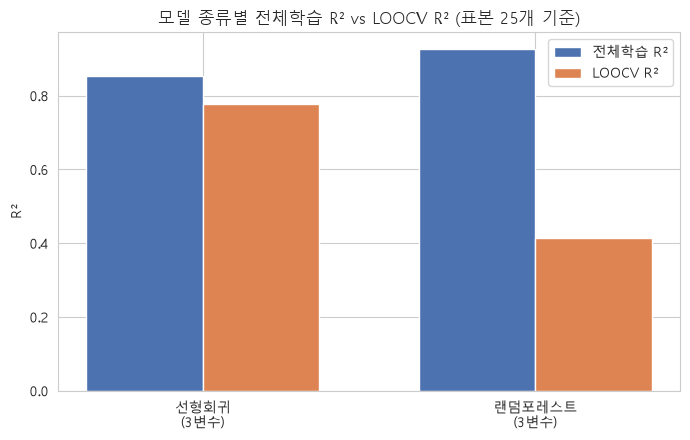

In [13]:
fig, ax = plt.subplots(figsize=(7, 4.5))
x_pos = np.arange(2)
width = 0.35
ax.bar(x_pos - width/2, 비교표_모델종류["전체학습_R2"], width, label="전체학습 R²", color="#4C72B0")
ax.bar(x_pos + width/2, 비교표_모델종류["LOOCV_R2"], width, label="LOOCV R²", color="#DD8452")
ax.set_xticks(x_pos)
ax.set_xticklabels(["선형회귀\n(3변수)", "랜덤포레스트\n(3변수)"])
ax.set_ylabel("R²")
ax.set_title("모델 종류별 전체학습 R² vs LOOCV R² (표본 25개 기준)")
ax.legend()
plt.tight_layout()
plt.savefig(프로젝트_루트 + r"\reports\figures\모델링_선형회귀_vs_랜덤포레스트.png", dpi=130)
plt.show()

## STEP 7. 최종 모델 저장

In [14]:
저장_경로 = 프로젝트_루트 + r"\data\processed\서울_자치구_모델링결과.csv"
df.to_csv(저장_경로, index=False, encoding="utf-8-sig")
print("저장 완료 ->", 저장_경로)

저장 완료 -> C:\Users\seokho\Desktop\엘리스\ABA_1st_proj_수정\data\processed\서울_자치구_모델링결과.csv


## 정리 — 다음 단계로 넘어갈 준비

- **최종 채택 모델**: `카페1개당_평균매출 ~ log(총_직장_인구_수) + 총_가구_수 + 집객시설_수` (선형회귀). LOOCV R² = 0.78로 기준선(직장인구 1개, LOOCV R² = 0.61) 대비 뚜렷하게 개선됐고, 전체학습-LOOCV 차이(0.08)도 크지 않아 과적합이 아닌 진짜 설명력 향상으로 판단합니다.
- **변수 3개가 한계인 이유**: 표본이 자치구 25개뿐이라, 4번째 변수를 추가해도 LOOCV가 더 좋아지지 않는 걸 직접 확인했습니다(과적합 시작 지점).
- **다른 모델(랜덤포레스트)은 왜 안 썼는가**: 같은 조건으로 직접 돌려본 결과 전체학습 R²는 더 높지만 LOOCV R²는 0.41로 뚝 떨어져(과적합 0.51) 표본 25개에는 맞지 않는다는 걸 결과로 확인했습니다. 해석 가능성(계수로 설명 가능)도 이 프로젝트 목표에 더 부합합니다.
- **잔차 상위/하위 지역**(관악구·중구·동작구 / 용산구·구로구)은 이 3변수만으로 설명 안 되는 지점이라, `3.0-insights.ipynb`에서 행정동 단위로 좁혀 들여다봅니다.
- **모델 가정 점검**: VIF는 세 변수 모두 3 미만으로 다중공선성이 심각한 수준은 아니며, statsmodels OLS로 확인한 계수 유의성도 세 변수 모두 p<0.05입니다. 다만 표본이 25개뿐이라 신뢰구간이 넓은 편이라, 계수 크기를 "순수한 영향력"으로 과신하지 않고 방향성(양/음) 위주로 해석합니다.
- **한계(선택편향)**: 후보 변수를 순서대로 시도하며 LOOCV가 가장 좋은 조합을 고르는 방식은, 표본이 25개뿐인 상황에서 순수 우연으로 점수가 좋아 보일 위험이 있다는 걸 난수 실험으로 직접 확인했습니다. 후보를 관련성 있는 변수로 제한하고 계수 해석 가능성으로 재확인했지만, 위험을 완전히 배제할 수는 없어 향후 더 많은 데이터로 재검증이 필요한 지점입니다.

이 내용을 바탕으로 `3.0-insights.ipynb`에서 행정동 단위 최종 후보를 좁히고, 상관관계와 인과관계를 구분해서 비즈니스 인사이트로 정리합니다.